경사하강법
반동 횟수로 추정하는것 

정확도보다는 속도가 빨라져서 장점이 있음



sgd > 앞에서 나온 모든 규제 사용~!

데이터가 많을때,


max_iter 반동수!

# [LAB 07] 지도학습 > 예측 > 선형 >규제적용 > SGDRegressor

## #01. 확률적 경사하강법 개요
- 선형회귀에 규제 (L1,L2,ElasticNet) 을 적용하고, 확률적 경사하강법으로 해를 찾는 회귀 모델
  
### [1] 기존 규제 회귀 (Ridge , Lasso , ElasticNet)
- 데이터가 커질수록 계산 비용 증가
- 전체 데이터를 한번에 사용
> SGDRegressor 는 데이터를 조금씩 보며 빠르게 학습


### [2] 핵심 아이디어
- 한번에 전체 데이터 x
- 한 샘플씩 반복 업데이터
- 대규모 데이터 에서도 학습 가능
- 정확한 계산보다는 빠르게 근사하는데에 초점을 맞춤
  ex) 웹사이트 추천 서비스 같이 실시간 학습 필요할때




### [3] 적용 가능한 규제
|penalty 값 | 적용 규제 | 대응 모델|
|-|-|
|l2|L2규제|Ridge|
|l1|L1규제|Lasso|
|elasticnet|L1+L2|ElasticNet|
|None|규제없음|OLS유사|

- 규제 강도는 alpha 로 조절


### [4] 언제 쓰면 좋은가?
- 데이터 규모가 클떄
- 실시간 학습 필요할 때
- 메모리 제약 존재할 때


## #2.준비작업
### [1] 패키지 참조

In [1]:
from hossam import *
from pandas import DataFrame, read_excel
from matplotlib import pyplot as plt
import seaborn as sb
import numpy as np
import statsmodels as sm


#데이터 표준화 모듈
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,GridSearchCV,learning_curve



#성능 평가 지표 모듈
from sklearn.metrics import(
  r2_score,
  mean_absolute_error,
  mean_squared_error,
  mean_absolute_percentage_error
)

#라쏘 회귀
from sklearn.linear_model import SGDRegressor

### [2] 데이터 가져오기

In [2]:
origin = load_data('fish_processed')
origin.head()

농어의 길이,높이,두께,무게를 조사한 데이터의 전처리 버전


,길이,높이,두께,무게
0,8.4,2.11,1.41,1.931521
1,13.7,3.53,2.00,3.496508
2,15.0,3.82,2.43,3.713572
3,16.2,4.59,2.63,3.960813
4,17.4,4.59,2.94,4.262680


### [3] 훈련,검증 데이터 분리

In [3]:
df = origin

yname = '무게'
x=df.drop(columns=[yname])
y=df[yname]


x_train,x_test,y_train,y_test = train_test_split(
  x,y,test_size=0.25,random_state=52
)

x_train.shape,x_test.shape,y_train.shape,y_test.shape

((42, 3), (14, 3), (42,), (14,))

## #03. SGD 회귀 (SGDRegressor) 모형 적합
### [1] 주요 하이퍼 파라미터
- SGD 회귀 튜닝은 penalty (규제 종류) 와 alpha(규제강도),
  그리고 학습 과정 제어 파라미터를 조정하는 것에 초점


| 하이퍼파라미터    | 의미        | 기본값 (sklearn) | 역할                       | 값 설정 가이드                                                      |
| ---------- | --------- | ------------- | ------------------------ | ------------------------------------------------------------- |
| `penalty`  | 규제 종류     | `"l2"`        | 적용할 규제 방식 선택             | `"l2"` → Ridge 성향<br>`"l1"` → Lasso 성향<br>`"elasticnet"` → 혼합 |
| `alpha`    | 규제 강도 (λ) | `0.0001`      | 계수 크기 억제 수준 결정           | 작게 → 규제 약함<br>크게 → 과적합 억제 강화                                  |
| `l1_ratio` | L1 비율     | `0.15`        | elasticnet 사용 시 L1/L2 비율 | `0` → Ridge 성향<br>`1` → Lasso 성향                              |
| `max_iter` | 최대 반복 횟수  | `1000`        | 학습 반복 한계                 | 수렴 경고 시 증가                                                    |
|`learing_rate`| 학습률 전략|invsaling|학습률 감소 방식|기본값 유지 권장|
|`random_state`|난수 시드| None|학습 순서 재현성|실험 재현시 설정|



### 핵심 정리
🔹 가장 중요한 파라미터
- penalty : 어떤 규제를 쓸지
- alpha : 규제를 얼마나 세게 줄지

🔹 penalty="elasticnet" 일 때
- l1_ratio 로 변수 선택 vs 안정성 조절
- L1 비중 ↑ → 변수 선택 강화
- L2 비중 ↑ → 계수 안정성 강화

🔹 SGD 회귀는
- 확률적 경사하강법 기반
- 반복 학습 및 학습률 설정에 민감

🔹 GridSearchCV에서는
- penalty × alpha × l1_ratio
- → 조합 탐색 가능

🔹 나머지 파라미터들은
- 수렴 안정성 / 재현성 보조용


🔹 실무에서는
- 기본 학습률 전략 유지 대부분의 경우
- penalty , alpha (필요 시) l1_ratio 만 튜닝

### 주의사항
- max_iter 설정 값 안에 수렴하지 못할 경우
→ 경고 메시지 출력

🔹 GridSearchCV 사용 시 주의
- 모든 penalty × 모든 learning_rate 조합 사용 시
→ 조합 폭발
- 일부 조합은 의도적으로 수렴이 느림
- 경고 발생 가능 (정상적인 현상)

### [2] 모델 적합
- 반드시 스케일링을 적용해야한다.
- 지금 사용하는 데이터셋은 FISH 데이터셋에 로그 > 스케일링이 적용된 결과에 이이서 진행하는 것이므로 이 예제에서는 직접적으로 스케일링을 처리하지 않는다

In [4]:
%%time
#SGDRegressor 를 위한 경고 무시 설정
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore',category=ConvergenceWarning)

#SGDRegressor 모델 정의 (n_jobs 없음)

pipe = Pipeline([('scaler', StandardScaler()) , ('model',SGDRegressor(random_state=52))])


#탐색할 하이퍼파라미터 그리드 설정
param_grid = {'model__alpha':[0.01,0.1,1,10,100]}

#그리드 서치 객체 생성
gs = GridSearchCV(estimator=pipe,param_grid=param_grid,cv=5,scoring='r2',n_jobs=-1)


gs.fit(x_train,y_train)

estimator=gs.best_estimator_

estimator

CPU times: total: 125 ms
Wall time: 2.89 s


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"loss loss: str, default='squared_error'The loss function to be used. The possible values are 'squared_error','huber', 'epsilon_insensitive', or 'squared_epsilon_insensitive'The 'squared_error' refers to the ordinary least squares fit.'huber' modifies 'squared_error' to focus less on getting outlierscorrect by switching from squared to linear loss past a distance ofepsilon. 'epsilon_insensitive' ignores errors less than epsilon and islinear past that; this is the loss function used in SVR.'squared_epsilon_insensitive' is the same but becomes squared loss pasta tolerance of epsilon.More details about the losses formulas can be found in the:ref:`User Guide `.",'squared_error'
,"penalty penalty: {'l2', 'l1', 'elasticnet', None}, default='l2'The penalty (aka regularization term) to be used. Defaults to 'l2'which is the standard regularizer for linear SVM models. 'l1' and'elasticnet' might bring sparsity to the model (feature selection)not achievable with 'l2'. No penalty is added when set to `None`.You can see a visualisation of the penalties in:ref:`sphx_glr_auto_examples_linear_model_plot_sgd_penalties.py`.",'l2'
,"alpha alpha: float, default=0.0001Constant that multiplies the regularization term. The higher thevalue, the stronger the regularization. Also used to compute thelearning rate when `learning_rate` is set to 'optimal'.Values must be in the range `[0.0, inf)`.",0.1
,"l1_ratio l1_ratio: float, default=0.15The Elastic Net mixing parameter, with 0 <= l1_ratio <= 1.l1_ratio=0 corresponds

## #04.성능 평가
### [1] 성능 평가 지표

In [5]:
y_pred = estimator.predict(x_test)


result_df = DataFrame(
    {
        "결정계수(R2)": r2_score(y_test, y_pred),
        "평균절대오차(MAE)": mean_absolute_error(y_test, y_pred),
        "평균제곱오차(MSE)": mean_squared_error(y_test, y_pred),
        "평균오차(RMSE)": np.sqrt(mean_squared_error(y_test, y_pred)),
        "평균 절대 백분오차(MAPE)": mean_absolute_percentage_error(y_test, y_pred),
        "평균 비율 오차(MPE)": np.mean((y_test - y_pred) / y_test * 100),
    },
    index=["성능지표"],
)

result_df


,결정계수(R2),평균절대오차(MAE),평균제곱오차(MSE),평균오차(RMSE),평균 절대 백분오차(MAPE),평균 비율 오차(MPE)
성능지표,0.982312,0.118207,0.020531,0.143287,0.022537,1.565647


### [2] 과적합 여부 확인

In [7]:
# ==========================
# # 과적합 여부 확인
# ==========================

# 반드시 원본 데이터 적용
train_sizes, train_scores, cv_scores = learning_curve(
    estimator=estimator,
    X=x,
    y=y,
    cv=5,
    scoring="neg_root_mean_squared_error",
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True,
    random_state=52,
    n_jobs=-1,
)

# neg RMSE -> RMSE
train_rmse = -train_scores
cv_rmse = -cv_scores

# 평균 / 표준편차
train_mean = train_rmse.mean(axis=1)
cv_mean = cv_rmse.mean(axis=1)
cv_std = cv_rmse.std(axis=1)

# 마지막 지점 기준 경향 판정
final_train = train_mean[-1]
final_cv = cv_mean[-1]
final_std = cv_std[-1]
gap_ratio = final_train / final_cv
var_ratio = final_std / final_cv

# --------------------------
# # 과적합 기준선 (some_threshold)
# --------------------------

# 기준모형 RMSE (평균예측)
y_mean = y.mean()
rmse_naive = np.sqrt(np.mean((y - y_mean) ** 2))

# 분산 기반
std_y = y.std()

# 최소 설명력(R^2) 기반
min_r2 = 0.10
rmse_r2 = np.sqrt((1 - min_r2) * np.var(y))

# 최종 threshold (가장 관대한 기준)
# -> 원래 some_threshold는 도메인 지식 수준에서 이 모델은 최소 어느 정도 성능은 내야 한다는 기준을 설정하는 것
some_threshold = min(rmse_naive, std_y, rmse_r2)

# --------------------------
# # 판정 로직
# --------------------------
if gap_ratio >= 0.95 and final_cv > some_threshold:
    status = "⚠️과소적합 (bias 큼)"
elif gap_ratio <= 0.8:
    status = "⚠️과대적합 (variance 큼)"
elif gap_ratio <= 0.95 and var_ratio <= 0.10:
    status = "✅일반화 양호"
elif var_ratio > 0.15:
    status = "⚠️데이터 부족 / 분산 큼"
else:
    status = "⚠️판단 유보"



# ==========================
# # 정량 결과 표
# ==========================
result_df = DataFrame(
    {
        "지표": [
            "Train RMSE",
            "CV RMSE 평균",
            "CV RMSE 표준편차",
            "Train/CV 비율",
            "CV 변동성 비율",
            "판정 결과",
        ],
        "값": [
            final_train,
            final_cv,
            final_std,
            gap_ratio,
            var_ratio,
            status,
        ],
    }
)

result_df


,지표,값
0,Train RMSE,0.233934
1,CV RMSE 평균,0.328965
2,CV RMSE 표준편차,0.158383
3,Train/CV 비율,0.711121
4,CV 변동성 비율,0.48146
5,판정 결과,⚠️과대적합 (variance 큼)


### [3] 학습 곡선

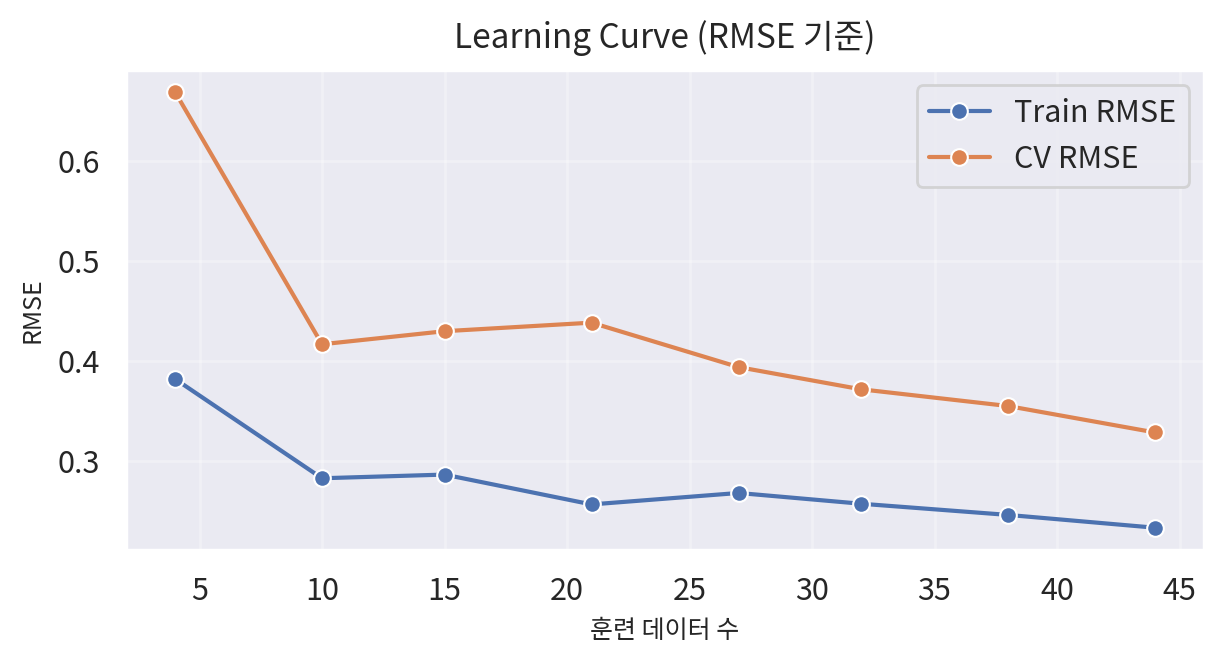

In [9]:
# ==========================
# # 시각화 (Learning Curve)
# ==========================
figsize = (1280 / my_dpi, 720 / my_dpi)
fig, ax = plt.subplots(1, 1, figsize=figsize, dpi=my_dpi)

sb.lineplot(
    x=train_sizes,
    y=train_mean,
    marker="o",
    label="Train RMSE",
    ax=ax,
)
sb.lineplot(
    x=train_sizes,
    y=cv_mean,
    marker="o",
    label="CV RMSE",
    ax=ax,
)

ax.set_title("Learning Curve (RMSE 기준)", fontsize=12, pad=8)
ax.set_xlabel("훈련 데이터 수", fontsize=9)
ax.set_ylabel("RMSE", fontsize=9)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()
plt.close()